In [1]:
import datetime
import glob

import cmocean.cm as cmo
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr

from scipy import interpolate

import parcels

/tmp/ipykernel_3517683/2885254657.py:14: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
animals_to_exclude = ["CC17", "CC29", "CC30"]
files = sorted([file for file in glob.glob("Loggerhead_Simulation_C*.parquet") if not any(animal in file for animal in animals_to_exclude)])

CC13 @ 12C: Mean drift time: 16.36 days, Max drift time: 21 days, Min drift time: 10 days
CC14 @ 12C: Mean drift time: 17.37 days, Max drift time: 20 days, Min drift time: 11 days
CC15 @ 12C: Mean drift time: 25.69 days, Max drift time: 31 days, Min drift time: 21 days
CC16 @ 12C: Mean drift time: 16.1 days, Max drift time: 19 days, Min drift time: 13 days
CC18 @ 12C: Mean drift time: 35.72 days, Max drift time: 59 days, Min drift time: 28 days
CC19 @ 12C: Mean drift time: 34.48 days, Max drift time: 60 days, Min drift time: 28 days
CC20 @ 12C: Mean drift time: 44.03 days, Max drift time: 67 days, Min drift time: 38 days
CC21 @ 12C: Mean drift time: 66.46 days, Max drift time: 73 days, Min drift time: 40 days
CC22 @ 12C: Mean drift time: 61.29 days, Max drift time: 74 days, Min drift time: 40 days
CC23 @ 12C: Mean drift time: 59.82 days, Max drift time: 90 days, Min drift time: 48 days
CC24 @ 12C: Mean drift time: 89.71 days, Max drift time: 90 days, Min drift time: 85 days
CC25 @ 12C:

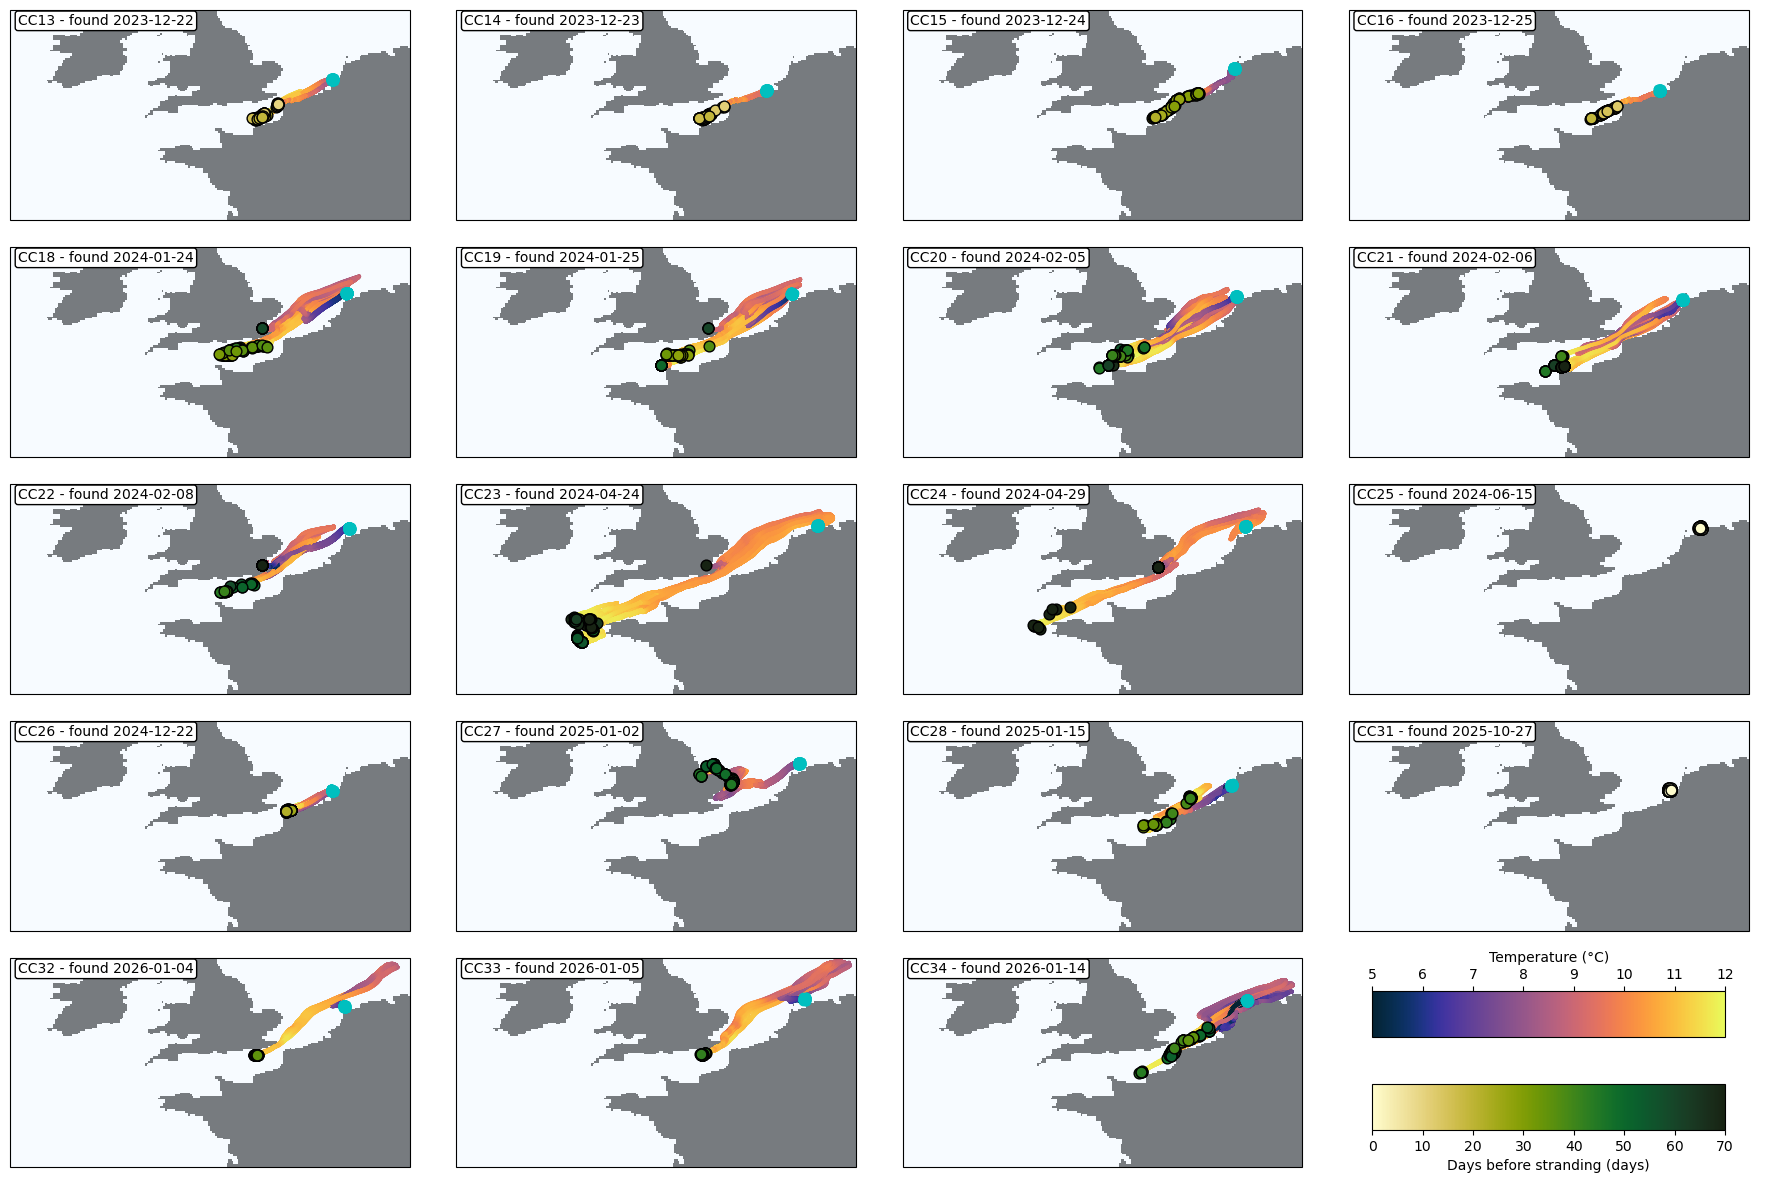

CC13 @ 14C: Mean drift time: 30.08 days, Max drift time: 31 days, Min drift time: 27 days
CC14 @ 14C: Mean drift time: 31.25 days, Max drift time: 32 days, Min drift time: 31 days
CC15 @ 14C: Mean drift time: 35.13 days, Max drift time: 40 days, Min drift time: 33 days
CC16 @ 14C: Mean drift time: 34.19 days, Max drift time: 52 days, Min drift time: 32 days
CC18 @ 14C: Mean drift time: 64.31 days, Max drift time: 76 days, Min drift time: 51 days
CC19 @ 14C: Mean drift time: 65.83 days, Max drift time: 77 days, Min drift time: 51 days
CC20 @ 14C: Mean drift time: 78.95 days, Max drift time: 88 days, Min drift time: 63 days
CC21 @ 14C: Mean drift time: 77.5 days, Max drift time: 87 days, Min drift time: 65 days
CC22 @ 14C: Mean drift time: 87.15 days, Max drift time: 90 days, Min drift time: 67 days
CC23 @ 14C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC24 @ 14C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC25 @ 14C: M

<Figure size 640x480 with 0 Axes>

CC13 @ 16C: Mean drift time: 51.68 days, Max drift time: 59 days, Min drift time: 47 days
CC14 @ 16C: Mean drift time: 50.85 days, Max drift time: 59 days, Min drift time: 48 days
CC15 @ 16C: Mean drift time: 53.39 days, Max drift time: 63 days, Min drift time: 51 days
CC16 @ 16C: Mean drift time: 56.37 days, Max drift time: 63 days, Min drift time: 50 days
CC18 @ 16C: Mean drift time: 87.97 days, Max drift time: 90 days, Min drift time: 83 days
CC19 @ 16C: Mean drift time: 87.23 days, Max drift time: 90 days, Min drift time: 84 days
CC20 @ 16C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC21 @ 16C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC22 @ 16C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC23 @ 16C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC24 @ 16C: Mean drift time: 90.0 days, Max drift time: 90 days, Min drift time: 90 days
CC25 @ 16C: Mea

<Figure size 640x480 with 0 Axes>

In [ ]:
ds_fld = xr.open_dataset("copernicus_physics.nc")
land_mask_condition = (ds_fld.U.data[0, 0, :, :] == 0) & \
                      (ds_fld.V.data[0, 0, :, :] == 0)
landmask = np.ma.masked_where(land_mask_condition, land_mask_condition)
lon, lat = ds_fld.lon, ds_fld.lat
lon_centers = lon[1:] - np.diff(lon) / 2
lat_centers = lat[1:] - np.diff(lat) / 2
x, y = np.meshgrid(lon_centers, lat_centers)

fl = interpolate.RectBivariateSpline(lat, lon, landmask.mask, kx=1, ky=1)
lmask = (fl(y[:, 0], x[0, :]) > 0.95).astype(int)
ds_fld.close()

for mintemp in [12, 14, 16]:
    fig, axes = plt.subplots(5, 4, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf

    for i, file in enumerate(files):
        df = parcels.read_particlefile(file)
        df = df.with_columns(
            pl.col("temperature").replace(0, np.nan).alias("temperature")
        )
        xmin = min(xmin, df["x"].min())
        xmax = max(xmax, df["x"].max())
        ymin = min(ymin, df["y"].min())
        ymax = max(ymax, df["y"].max())

        ax = axes[i // 4, i % 4]
        ax.set_facecolor('aliceblue')

        ax.pcolormesh(x, y, lmask, cmap='Greys', alpha=0.5, zorder=0)

        drifttimes = np.zeros((100, 1), dtype=int)
        for traj in df.partition_by("particle_id", maintain_order=True):

            temp = np.asarray(traj["temperature"])
            warm_idx = np.flatnonzero(temp > mintemp)

            if warm_idx.size == 0:
                frozen = len(temp) - 1
            elif warm_idx.size == 1:
                frozen = int(warm_idx[0])
            else:
                frozen = int(warm_idx[1])
            drifttime = (traj["t"][0] - traj["t"][frozen]).days
            drifttimes[traj["particle_id"][0]] = drifttime

            scat = ax.scatter(
                traj["x"][:frozen],
                traj["y"][:frozen],
                c=traj["temperature"][:frozen],
                s=3,
                zorder=3,
                cmap=cmo.thermal,
                vmin=5,
                vmax=mintemp,
            )
            ax.plot(traj["x"][0], traj["y"][0], "co", zorder=4)
            age = ax.scatter(
                traj["x"][frozen],
                traj["y"][frozen],
                c=drifttime,
                s=60,
                zorder=5,
                cmap=cmo.speed,
                vmin=0,
                vmax=70,
                edgecolor='k',
            )

        ax.set_xlim([-12, 8])
        ax.set_ylim([45, 55.5])
        ID = file.split('_')[-1].split('.')[0]
        beach_date = df['t'].max().strftime('%Y-%m-%d')
        ax.text(
            0.02, 0.96, f"{ID} - found {beach_date}",
            transform=ax.transAxes,
            ha="left", va="top", fontsize=10, zorder=6,
            bbox=dict(facecolor="white", edgecolor="black", linewidth=1.0, boxstyle="round,pad=0.2")
        )

        print(f"{ID} @ {mintemp}C: Mean drift time: {drifttimes.mean()} days, Max drift time: {drifttimes.max()} days, Min drift time: {drifttimes.min()} days")

    # print(f"Overall bounds: x: [{xmin}, {xmax}], y: [{ymin}, {ymax}]")
    axes[-1, -1].axis("off")

    cax_top = axes[-1, -1].inset_axes([0.08, 0.62, 0.84, 0.22])
    cax_bottom = axes[-1, -1].inset_axes([0.08, 0.18, 0.84, 0.22])

    cbar_temp = fig.colorbar(scat, cax=cax_top, orientation="horizontal")
    cbar_temp.set_label("Temperature (°C)")
    cbar_temp.ax.xaxis.set_label_position("top")
    cbar_temp.ax.xaxis.set_ticks_position("top")  # optional: move ticks to top too

    cbar_age = fig.colorbar(age, cax=cax_bottom, orientation="horizontal")
    cbar_age.set_label("Days before stranding")

    plt.tight_layout()
    plt.savefig(f"loggerhead_combined_plot_{mintemp}C.png", dpi=300, bbox_inches='tight')
    plt.show()